In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

import sklearn
from sklearn import metrics
from sklearn import model_selection
from sklearn import preprocessing
from sklearn import impute
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer

from scipy.stats import chi2_contingency
from scipy import sparse

from funcs import *

set_config(transform_output="pandas")
pd.set_option('future.no_silent_downcasting', True)

# Cargar Datos
Aqui dejamos adjunta la [fuente de los datos](https://www.kaggle.com/datasets/shivamb/real-or-fake-fake-jobposting-prediction).

In [2]:
url = 'https://raw.githubusercontent.com/AitzolSa/dataset/619ecb7ffa2bdfcfb5a589fb8266bcf0db15250d/archive.zip'

print("Descargando y leyendo el dataset...")
X = pd.read_csv(url, compression='zip')

print("Datos cargados con exito:")
X.head()

Descargando y leyendo el dataset...
Datos cargados con exito:


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


# Dividir Train, Val y Test

In [3]:
# Dividimos train, test y validacion
semilla = 69

y = X.fraudulent
X_features = X.drop('fraudulent', axis=1)
X_resto, X_test, y_resto, y_test = model_selection.train_test_split(
    X_features, y, random_state=semilla, stratify=y, test_size=0.1
)
X_train, X_val, y_train, y_val = model_selection.train_test_split(
    X_resto, y_resto, random_state=semilla, stratify=y_resto, test_size=0.2
)

print("Train:")
print(X_train.describe())
print()

print("Val:")
print(X_val.describe())
print()

print("Test:")
print(X_test.describe())

Train:
             job_id  telecommuting  has_company_logo  has_questions
count  12873.000000   12873.000000      12873.000000   12873.000000
mean    8919.432533       0.042880          0.796784       0.492737
std     5167.644356       0.202595          0.402408       0.499967
min        2.000000       0.000000          0.000000       0.000000
25%     4408.000000       0.000000          1.000000       0.000000
50%     8935.000000       0.000000          1.000000       0.000000
75%    13380.000000       0.000000          1.000000       1.000000
max    17880.000000       1.000000          1.000000       1.000000

Val:
             job_id  telecommuting  has_company_logo  has_questions
count   3219.000000    3219.000000       3219.000000    3219.000000
mean    8991.802423       0.042249          0.788444       0.483691
std     5157.263804       0.201188          0.408475       0.499812
min        1.000000       0.000000          0.000000       0.000000
25%     4594.500000       0.000000 

# ModeloBase

Empezando fit
Empezando a predecir
Resultado de la prueba 0: 0.5894145886602783


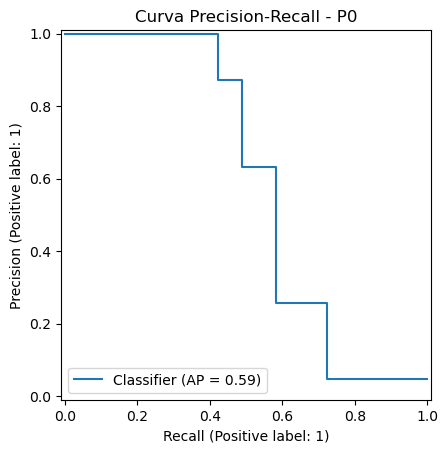

In [5]:
categoricas = ['title','location','department','salary_range','description','company_profile','requirements','benefits',
 'employment_type','required_experience','required_education','industry','function']

numericas = ['telecommuting', 'has_company_logo', 'has_questions']


transformerUnks = ColumnTransformer(transformers = [
    ("imputarUnks",
         impute.SimpleImputer(strategy='constant', fill_value='unk'), 
         categoricas),
    ("imputarNegs",
          impute.SimpleImputer(strategy='constant', fill_value=-1),
         X_train.select_dtypes(include=['number']).columns.tolist()),
    ("dropearVariables", 'drop', ['job_id']),
                                                   ],
                                    remainder='passthrough',
                                    verbose_feature_names_out=False 
                                   )

numerizar = ColumnTransformer(transformers=[
    ("target_enc", preprocessing.TargetEncoder(smooth="auto",random_state=semilla), 
     categoricas)    
], remainder='passthrough')

pipe0 = Pipeline([
    ("limpiaEspacios", limpiar_espacios()),
    ("minusculizar",minusculizar()),
    ("quitarSimbolos",quitar_simbolos()),
    ("quitarTildes",quitar_tildes()),
    ("rellenarGenerico",transformerUnks),
    ("numerizar", numerizar),
    ("knn", KNeighborsClassifier())
])

print("Empezando fit")
pipe0.fit(X_train,y_train)

print("Empezando a predecir")
preds0 = pipe0.predict_proba(X_val)[:, 1]

pr_auc_0 = metrics.average_precision_score(y_val,preds0)
print("Resultado de la prueba 0: {}".format(pr_auc_0))

metrics.PrecisionRecallDisplay.from_predictions(y_val, preds0)
plt.title("Curva Precision-Recall - P0")
plt.show()

# 1. Rellenado de Nulos

## Salary_range

### Rellenado 1-0

Empezando fit
Empezando a predecir
Resultado de la prueba 11: 0.8022599393351799


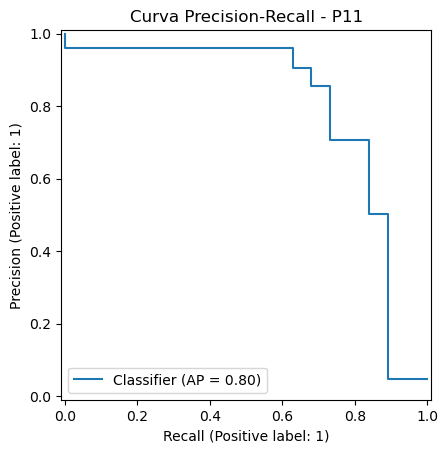

In [6]:
categoricas = ['title','location','department','description','company_profile','requirements','benefits',
 'employment_type','required_experience','required_education','industry','function']

numericas = ['telecommuting', 'has_company_logo', 'has_questions']


transformerUnksYSal = ColumnTransformer(transformers = [
    ("imputarUnks",
         impute.SimpleImputer(strategy='constant', fill_value='unk'), 
         categoricas),
    ("imputarSalario",TransformadorSalarioBinario(), ["salary_range"]),
    ("imputarNegs",
          impute.SimpleImputer(strategy='constant', fill_value=-1),
         numericas),
    ("dropearVariables", 'drop', ['job_id'])
                                                   ],
                                    remainder='passthrough',
                                    verbose_feature_names_out=False # Para que lo que devuelva sea legible (pone unas movidas que flipas)
                                   )

numerizar = ColumnTransformer(transformers=[
    ("target_enc", preprocessing.TargetEncoder(smooth="auto",random_state=semilla), categoricas)    
], remainder='passthrough')

pipe11 = Pipeline([
    ("limpiaEspacios", limpiar_espacios()),
    ("minusculizar",minusculizar()),
    ("quitarSimbolos",quitar_simbolos()),
    ("quitarTildes",quitar_tildes()),
    ("rellenarGenerico2",transformerUnksYSal),
    ("numerizar", numerizar),
    ("knn", KNeighborsClassifier())
])

print("Empezando fit")
pipe11.fit(X_train,y_train)

print("Empezando a predecir")
preds11 = pipe11.predict_proba(X_val)[:, 1]

pr_auc_11 = metrics.average_precision_score(y_val,preds11)
print("Resultado de la prueba 11: {}".format(pr_auc_11))

metrics.PrecisionRecallDisplay.from_predictions(y_val, preds11)
plt.title("Curva Precision-Recall - P11")
plt.show()

### Rellenado Discreto

Empezando train
Empezando a predecir
Resultado de la prueba 12: 0.8180336951235969


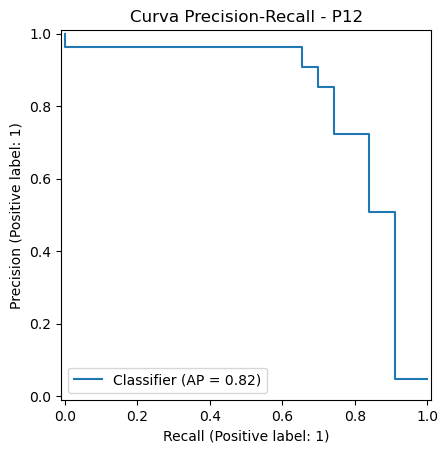

In [7]:
categoricas = ['title','location','department','description','company_profile','requirements','benefits',
 'employment_type','required_experience','required_education','industry','function']

numericas = ['telecommuting', 'has_company_logo', 'has_questions']

transformerUnksYSal = ColumnTransformer(transformers = [
    ("imputarUnks",
         impute.SimpleImputer(strategy='constant', fill_value='unk'), 
         categoricas),
    ("imputarSalario",discretizador_salario(), ["salary_range"]),
    ("imputarNegs",
          impute.SimpleImputer(strategy='constant', fill_value=-1),
         ['telecommuting', 'has_company_logo', 'has_questions']),
    ("dropearVariables", 'drop', ['job_id'])
                                                   ],
                                    remainder='passthrough',
                                    verbose_feature_names_out=False # Para que lo que devuelva sea legible (pone unas movidas que flipas)
                                   )

numerizar = ColumnTransformer(transformers=[
    ("target_enc", preprocessing.TargetEncoder(smooth="auto",random_state=semilla), 
     categoricas + ["salary_range"])    
], remainder='passthrough')

pipe12 = Pipeline([
    ("limpiaEspacios", limpiar_espacios()),
    ("minusculizar",minusculizar()),
    ("quitarSimbolos",quitar_simbolos()),
    ("quitarTildes",quitar_tildes()),
    ("rellenarGenerico3",transformerUnksYSal),
    ("numerizar", numerizar),
    ("knn", KNeighborsClassifier())
])

print("Empezando train")
pipe12.fit(X_train,y_train)

print("Empezando a predecir")
preds12 = pipe12.predict_proba(X_val)[:, 1]

pr_auc_12 = metrics.average_precision_score(y_val,preds12)
print("Resultado de la prueba 12: {}".format(pr_auc_12))

metrics.PrecisionRecallDisplay.from_predictions(y_val, preds12)
plt.title("Curva Precision-Recall - P12")
plt.show()

## Resto de Variables

### Moda

Empezando train
Empezando a predecir
Resultado de la prueba 13: 0.8188849534992526


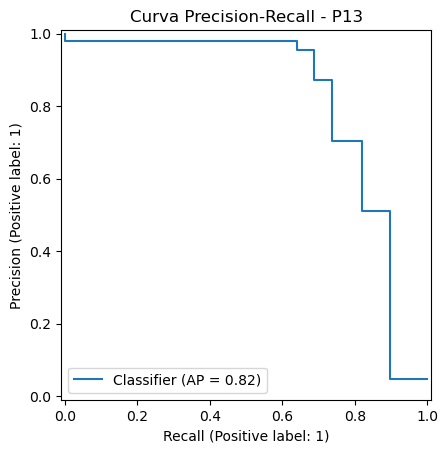

In [9]:
categoricas = ['title','location','department','description','company_profile','requirements','benefits',
 'employment_type','required_experience','required_education','industry','function']

numericas = ['telecommuting', 'has_company_logo', 'has_questions']

transformerUnksYSal = ColumnTransformer(transformers = [
    ("imputarModa",
         impute.SimpleImputer(strategy='most_frequent'), 
         categoricas + numericas),
    ("imputarSalario",discretizador_salario(), ["salary_range"]),
    ("dropearVariables", 'drop', ['job_id'])
                                                   ],
                                    remainder='passthrough',
                                    verbose_feature_names_out=False # Para que lo que devuelva sea legible (pone unas movidas que flipas)
                                   )

numerizar = ColumnTransformer(transformers=[
    ("target_enc", preprocessing.TargetEncoder(smooth="auto",random_state=semilla), 
     categoricas + ["salary_range"])    
], remainder='passthrough')

pipe13 = Pipeline([
    ("limpiaEspacios", limpiar_espacios()),
    ("minusculizar",minusculizar()),
    ("quitarSimbolos",quitar_simbolos()),
    ("quitarTildes",quitar_tildes()),
    ("rellenarGenerico3",transformerUnksYSal),
    ("numerizar", numerizar),
    ("knn", KNeighborsClassifier())
])

print("Empezando train")
pipe13.fit(X_train,y_train)

print("Empezando a predecir")
preds13 = pipe13.predict_proba(X_val)[:, 1]

pr_auc_13 = metrics.average_precision_score(y_val,preds13)
print("Resultado de la prueba 13: {}".format(pr_auc_13))

metrics.PrecisionRecallDisplay.from_predictions(y_val, preds13)
plt.title("Curva Precision-Recall - P13")
plt.show()

### Moda por grupos

Empezando train
Empezando a predecir
Resultado de la prueba 14: 0.777228728064281


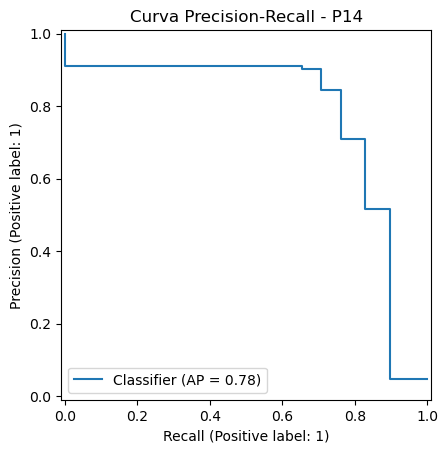

In [10]:
categoricas = ['title','location','department','description','company_profile','requirements','benefits',
 'employment_type','required_experience','required_education','industry','function']

numericas = ['telecommuting', 'has_company_logo', 'has_questions']

transformerNulls = ColumnTransformer(transformers = [
    ("imputarModa",
         impute.SimpleImputer(strategy='most_frequent'), 
         numericas + ["title","department"]), 
    ("imputarSalario",discretizador_salario(), ["salary_range"]),
    ("dropearVariables", 'drop', ['job_id'])
                                                   ],
                                    remainder='passthrough',
                                    verbose_feature_names_out=False 
                                   )

mg_agrup_1 = ["department","department"] 
mg_imput_1 = ["employment_type","industry"]

mg_agrup_2 = ["employment_type"] 
mg_imput_2 = ["required_experience"]

mg_agrup_3 = ["required_experience"] 
mg_imput_3 = ["required_education"]

transformerMG1 = ColumnTransformer(transformers = [
        ("agruparInclusion1",rellenar_moda_por_grupos(
            col_agrupacion = mg_agrup_1, 
            cols_a_imputar = mg_imput_1),["department","employment_type","industry"]),
],                 
                                    remainder='passthrough',
                                    verbose_feature_names_out=False 
                                   )

transformerMG2 = ColumnTransformer(transformers = [
        ("agruparInclusion2",rellenar_moda_por_grupos(
            col_agrupacion = mg_agrup_2, 
            cols_a_imputar = mg_imput_2),["employment_type","required_experience"]),
],                 
                                    remainder='passthrough',
                                    verbose_feature_names_out=False 
                                   )

transformerMG3 = ColumnTransformer(transformers = [
        ("agruparInclusion3",rellenar_moda_por_grupos(
            col_agrupacion = mg_agrup_3, 
            cols_a_imputar = mg_imput_3),["required_experience","required_education"]),
],                 
                                    remainder='passthrough',
                                    verbose_feature_names_out=False 
                                   )


pipeMG = Pipeline([("MG1",transformerMG1),("MG2",transformerMG2),("MG3",transformerMG3)])

numerizar = ColumnTransformer(transformers=[
    ("target_enc", preprocessing.TargetEncoder(smooth="auto",random_state=semilla), 
     categoricas + ["salary_range"])    
], remainder='passthrough')

pipe14 = Pipeline([
    ("limpiaEspacios", limpiar_espacios()),
    ("minusculizar",minusculizar()),
    ("quitarSimbolos",quitar_simbolos()),
    ("quitarTildes",quitar_tildes()),
    ("rellenarNulls",transformerNulls),
    ("rellenarMG",pipeMG),
    ("numerizar", numerizar),
    ("knn", KNeighborsClassifier())
])

print("Empezando train")
pipe14.fit(X_train,y_train)

print("Empezando a predecir")
preds14 = pipe14.predict_proba(X_val)[:, 1]

pr_auc_14 = metrics.average_precision_score(y_val,preds14)
print("Resultado de la prueba 14: {}".format(pr_auc_14))

metrics.PrecisionRecallDisplay.from_predictions(y_val, preds14)
plt.title("Curva Precision-Recall - P14")
plt.show()

# 2. Numerizacion de Variables Categoricas

## Contar Palabras y Contar Letras

Empezando train - contar palabras
Empezando a predecir - contar palabras
Resultado contar palabras: 0.6354770024544784


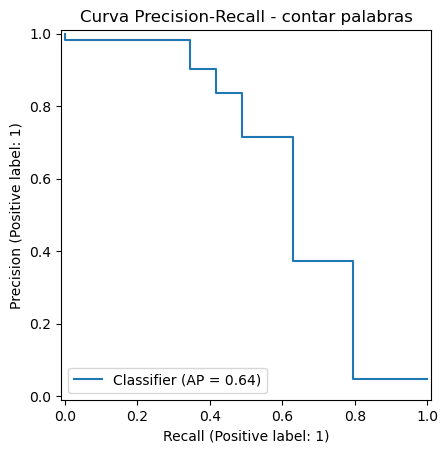

Empezando train - contar letras
Empezando a predecir - contar letras
Resultado contar letras: 0.6135667494107198


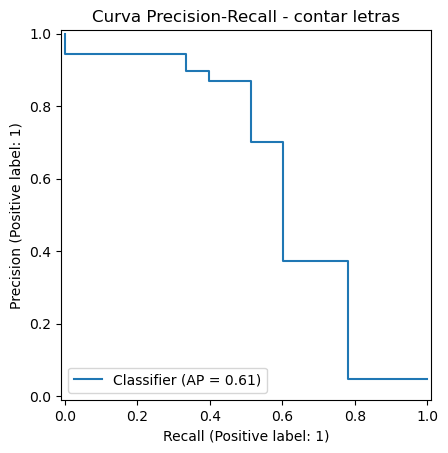

In [9]:
cols_texto_largo = ["company_profile", "description", "requirements"]

cols_categoricas_sin_texto_largo = ['title','location','department',
 'employment_type','required_experience','required_education','industry','function']

numericas = ['telecommuting', 'has_company_logo', 'has_questions']


transformerPalabras = ColumnTransformer(transformers=[
    ("contarPalabras",
        contar_palabras(),
        cols_texto_largo),

    ("imputarUnks",
        impute.SimpleImputer(strategy="constant", fill_value="unk"),
        cols_categoricas_sin_texto_largo),
    ("imputarSalario",discretizador_salario(), ["salary_range"]),
    ("imputarMedios",
        impute.SimpleImputer(strategy="constant", fill_value=-1),
        numericas),

    ("dropId",
        "drop",
        ["job_id"]),
],
    remainder="drop",
    verbose_feature_names_out=False
)

numerizarPalabras = ColumnTransformer(transformers=[
    ("target_enc",
        preprocessing.TargetEncoder(smooth="auto"),
        cols_categoricas_sin_texto_largo),

    ("imputar_y_escalar_texto",
        Pipeline([
            ("imputer", impute.SimpleImputer(strategy="constant", fill_value=-1)),
            ("scaler", preprocessing.StandardScaler())
        ]),
        cols_texto_largo),

    ("imputar_y_escalar_numericas",
        Pipeline([
            ("imputer", impute.SimpleImputer(strategy="constant", fill_value=-1)),
            ("scaler", preprocessing.StandardScaler())
        ]),
        numericas),
],
    remainder="drop",
    verbose_feature_names_out=False
)

pipePalabras = Pipeline([
    ("limpiaEspacios", limpiar_espacios()),
    ("minusculizar", minusculizar()),
    ("quitarSimbolos", quitar_simbolos()),
    ("quitarTildes", quitar_tildes()),
    ("rellenarGenerico", transformerPalabras),
    ("numerizar", numerizarPalabras),
    ("knn", KNeighborsClassifier())
])

print("Empezando train - contar palabras")
pipePalabras.fit(X_train, y_train)

print("Empezando a predecir - contar palabras")
preds_palabras = pipePalabras.predict_proba(X_val)[:, 1]

pr_auc_palabras = metrics.average_precision_score(y_val, preds_palabras)
print("Resultado contar palabras: {}".format(pr_auc_palabras))

metrics.PrecisionRecallDisplay.from_predictions(y_val, preds_palabras)
plt.title("Curva Precision-Recall - contar palabras")
plt.show()


transformerLetras = ColumnTransformer(transformers=[
    ("contarLetras",
        contar_letras(),
        cols_texto_largo),

    ("imputarUnks",
        impute.SimpleImputer(strategy="constant", fill_value="unk"),
        cols_categoricas_sin_texto_largo),

    ("imputarMedios",
        impute.SimpleImputer(strategy="constant", fill_value=-1),
        numericas),
    ("imputarSalario",discretizador_salario(), ["salary_range"]),

    ("dropId",
        "drop",
        ["job_id"]),
],
    remainder="drop",
    verbose_feature_names_out=False
)

numerizarLetras = ColumnTransformer(transformers=[
    ("target_enc",
        preprocessing.TargetEncoder(smooth="auto"),
        cols_categoricas_sin_texto_largo + ["salary_range"]),

    ("imputar_y_escalar_texto",
        Pipeline([
            ("imputer", impute.SimpleImputer(strategy="constant", fill_value=-1)),
            ("scaler", preprocessing.StandardScaler())
        ]),
        cols_texto_largo),

    ("imputar_y_escalar_numericas",
        Pipeline([
            ("imputer", impute.SimpleImputer(strategy="constant", fill_value=-1)),
            ("scaler", preprocessing.StandardScaler())
        ]),
        numericas),
],
    remainder="drop",
    verbose_feature_names_out=False
)

pipeLetras = Pipeline([
    ("limpiaEspacios", limpiar_espacios()),
    ("minusculizar", minusculizar()),
    ("quitarSimbolos", quitar_simbolos()),
    ("quitarTildes", quitar_tildes()),
    ("rellenarGenerico", transformerLetras),
    ("numerizar", numerizarLetras),
    ("knn", KNeighborsClassifier())
])

print("Empezando train - contar letras")
pipeLetras.fit(X_train, y_train)

print("Empezando a predecir - contar letras")
preds_letras = pipeLetras.predict_proba(X_val)[:, 1]

pr_auc_letras = metrics.average_precision_score(y_val, preds_letras)
print("Resultado contar letras: {}".format(pr_auc_letras))

metrics.PrecisionRecallDisplay.from_predictions(y_val, preds_letras)
plt.title("Curva Precision-Recall - contar letras")
plt.show()


## Binary Encoder

Total NaN antes del KNN: 0
Empezando train - Binary Encoder
Empezando a predecir - Binary Encoder
Resultado Binary Encoder: 0.6565863970068138


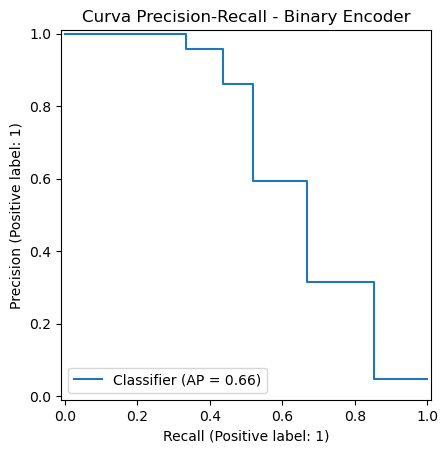

In [10]:
cols_texto_largo = ["company_profile", "description", "requirements"]

cols_categoricas_sin_texto_largo = ['title','location','department',
 'employment_type','required_experience','required_education','industry','function']

numericas = ['telecommuting', 'has_company_logo', 'has_questions']

transformerBinary = ColumnTransformer(transformers=[
    ("imputarUnks",
        impute.SimpleImputer(strategy="constant", fill_value="unk"),
        cols_texto_largo + cols_categoricas_sin_texto_largo),

    ("imputarMedios",
        impute.SimpleImputer(strategy="constant", fill_value=-1),
        numericas),
    ("imputarSalario",discretizador_salario(), ["salary_range"]),

    ("dropId",
        "drop",
        ["job_id"])
],
    remainder="drop",
    verbose_feature_names_out=False
)

pipeBinary = Pipeline([
    ("limpiaEspacios", limpiar_espacios()),
    ("minusculizar", minusculizar()),
    ("quitarSimbolos", quitar_simbolos()),
    ("quitarTildes", quitar_tildes()),
    ("rellenarGenerico", transformerBinary),

    ("binaryEncoder", BinaryEncoderSklearn(columnas=cols_categoricas_sin_texto_largo + cols_texto_largo + ["salary_range"])),

    ("imputarFinal",
        impute.SimpleImputer(strategy="constant", fill_value=-1)),

    ("scaler",
        preprocessing.StandardScaler()),

    ("knn",
        KNeighborsClassifier())
])


Xt_binary = pipeBinary[:-1].fit_transform(X_train, y_train)

print("Total NaN antes del KNN:", pd.DataFrame(Xt_binary).isna().sum().sum())


print("Empezando train - Binary Encoder")
pipeBinary.fit(X_train, y_train)

print("Empezando a predecir - Binary Encoder")
preds_binary = pipeBinary.predict_proba(X_val)[:, 1]

pr_auc_binary = metrics.average_precision_score(
    y_val,
    preds_binary
)

print("Resultado Binary Encoder: {}".format(pr_auc_binary))

metrics.PrecisionRecallDisplay.from_predictions(
    y_val,
    preds_binary
)

plt.title("Curva Precision-Recall - Binary Encoder")
plt.show()

## Target Encoder

Total NaN antes del KNN: 0
Empezando train - Target Encoder
Empezando a predecir - Target Encoder
Resultado Target Encoder: 0.851153569367463


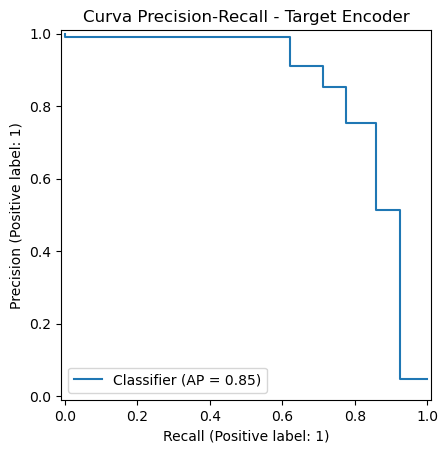

In [11]:
cols_categoricas = ['title','location','department',"company_profile", "description", "requirements",
 'employment_type','required_experience','required_education','industry','function']

numericas = ['telecommuting', 'has_company_logo', 'has_questions']


transformerTargetEncoder = ColumnTransformer(transformers=[
    ("imputarUnks",
        impute.SimpleImputer(strategy="constant", fill_value="unk"),
        cols_categoricas),

    ("imputarMedios",
        impute.SimpleImputer(strategy="constant", fill_value=-1),
        numericas),
    ("imputarSalario",discretizador_salario(), ["salary_range"]),

    ("dropId",
        "drop",
        ["job_id"]),
],
    remainder="passthrough",
    verbose_feature_names_out=False
)


numerizarTargetEncoder = ColumnTransformer(transformers=[
    ("target_enc",
        preprocessing.TargetEncoder(smooth="auto"),
        cols_categoricas),

    ("scaler",
        preprocessing.StandardScaler(),
        numericas),
],
    remainder="drop",
    verbose_feature_names_out=False
)


pipeTargetEncoder = Pipeline([
    ("limpiaEspacios", limpiar_espacios()),
    ("minusculizar", minusculizar()),
    ("quitarSimbolos", quitar_simbolos()),
    ("quitarTildes", quitar_tildes()),
    ("rellenarGenerico", transformerTargetEncoder),
    ("numerizar", numerizarTargetEncoder),
    ("knn", KNeighborsClassifier())
])


Xt_target = pipeTargetEncoder[:-1].fit_transform(X_train, y_train)

print("Total NaN antes del KNN:", pd.DataFrame(Xt_target).isna().sum().sum())

print("Empezando train - Target Encoder")
pipeTargetEncoder.fit(X_train, y_train)

print("Empezando a predecir - Target Encoder")
preds_target_encoder = pipeTargetEncoder.predict_proba(X_val)[:, 1]

pr_auc_target_encoder = metrics.average_precision_score(
    y_val,
    preds_target_encoder
)

print("Resultado Target Encoder: {}".format(pr_auc_target_encoder))

metrics.PrecisionRecallDisplay.from_predictions(
    y_val,
    preds_target_encoder
)

plt.title("Curva Precision-Recall - Target Encoder")
plt.show()

## Ordinal Encoder

Total NaN antes del KNN: 0
Empezando train - Ordinal Encoder
Empezando a predecir - Ordinal Encoder
Resultado Ordinal Encoder: 0.2205060373966487


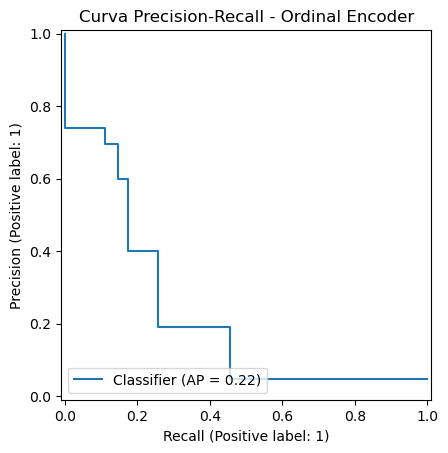

In [12]:
cols_categoricas = ['title','location','department',"company_profile", "description", "requirements",
 'employment_type','required_experience','required_education','industry','function']

numericas = ['telecommuting', 'has_company_logo', 'has_questions']


transformerOrdinalEncoder = ColumnTransformer(transformers=[
    ("imputarUnks",
        impute.SimpleImputer(strategy="constant", fill_value="unk"),
        cols_categoricas),

    ("imputarMedios",
        impute.SimpleImputer(strategy="constant", fill_value=-1),
        numericas),
    
    ("imputarSalario",discretizador_salario(), ["salary_range"]),

    ("dropId",
        "drop",
        ["job_id"]),
],
    remainder="passthrough",
    verbose_feature_names_out=False
)


numerizarOrdinalEncoder = ColumnTransformer(transformers=[
    ("ordinal_enc",
        preprocessing.OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
        ),
        cols_categoricas),

    ("scaler",
        preprocessing.StandardScaler(),
        numericas),
],
    remainder="drop",
    verbose_feature_names_out=False
)


pipeOrdinalEncoder = Pipeline([
    ("limpiaEspacios", limpiar_espacios()),
    ("minusculizar", minusculizar()),
    ("quitarSimbolos", quitar_simbolos()),
    ("quitarTildes", quitar_tildes()),
    ("rellenarGenerico", transformerOrdinalEncoder),
    ("numerizar", numerizarOrdinalEncoder),
    ("knn", KNeighborsClassifier())
])


Xt_ordinal = pipeOrdinalEncoder[:-1].fit_transform(X_train, y_train)

print("Total NaN antes del KNN:", pd.DataFrame(Xt_ordinal).isna().sum().sum())

print("Empezando train - Ordinal Encoder")
pipeOrdinalEncoder.fit(X_train, y_train)

print("Empezando a predecir - Ordinal Encoder")
preds_ordinal_encoder = pipeOrdinalEncoder.predict_proba(X_val)[:, 1]

pr_auc_ordinal_encoder = metrics.average_precision_score(
    y_val,
    preds_ordinal_encoder
)

print("Resultado Ordinal Encoder: {}".format(pr_auc_ordinal_encoder))

metrics.PrecisionRecallDisplay.from_predictions(
    y_val,
    preds_ordinal_encoder
)

plt.title("Curva Precision-Recall - Ordinal Encoder")
plt.show()

## Count Vectorizer

Transformación CountVectorizer hecha correctamente
Shape antes del KNN: (12873, 2012)
La matriz es sparse
Empezando train - CountVectorizer
Empezando a predecir - CountVectorizer
Resultado CountVectorizer: 0.6761949061133948


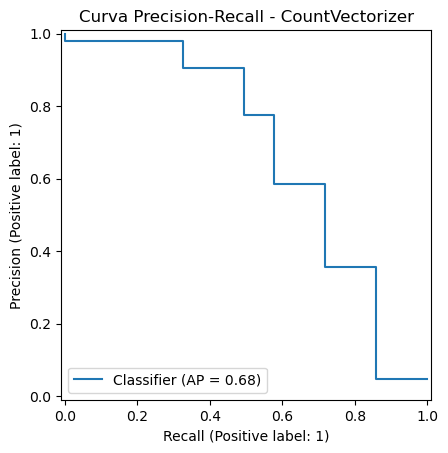

In [15]:
sklearn.set_config(transform_output="default")

cols_texto_largo = ["company_profile", "description", "requirements"]

cols_categoricas_sin_texto_largo = ['title','location','department',
 'employment_type','required_experience','required_education','industry','function']

numericas = ['telecommuting', 'has_company_logo', 'has_questions']


def pasar_a_texto_1d(X):
    X_df = pd.DataFrame(X).copy()
    return X_df.iloc[:, 0].fillna("unk").astype(str).values


preprocesadorCountVectorizer = ColumnTransformer(transformers=[
    ("target_enc",
        Pipeline([
            ("imputer", impute.SimpleImputer(strategy="constant", fill_value="unk")),
            ("target", preprocessing.TargetEncoder(smooth="auto"))
        ]),
        cols_categoricas_sin_texto_largo),

     ("salary",
        Pipeline([
            ("imputarSalario",discretizador_salario()),
            ("target", preprocessing.TargetEncoder(smooth="auto"))
        ]),
        ["salary_range"]),

    ("numericas",
        Pipeline([
            ("imputer", impute.SimpleImputer(strategy="constant", fill_value=-1)),
            ("scaler", preprocessing.StandardScaler())
        ]),
        numericas),

    ("count_company_profile",
        Pipeline([
            ("to_1d", preprocessing.FunctionTransformer(pasar_a_texto_1d, validate=False)),
            ("count", CountVectorizer(max_features=500))
        ]),
        ["company_profile"]),

    ("count_description",
        Pipeline([
            ("to_1d", preprocessing.FunctionTransformer(pasar_a_texto_1d, validate=False)),
            ("count", CountVectorizer(max_features=1000))
        ]),
        ["description"]),

    ("count_requirements",
        Pipeline([
            ("to_1d", preprocessing.FunctionTransformer(pasar_a_texto_1d, validate=False)),
            ("count", CountVectorizer(max_features=500))
        ]),
        ["requirements"]),

    ("dropId",
        "drop",
        ["job_id"]),
],
    remainder="drop",
    verbose_feature_names_out=False
)


pipeCountVectorizer = Pipeline([
    ("limpiaEspacios", limpiar_espacios()),
    ("minusculizar", minusculizar()),
    ("quitarSimbolos", quitar_simbolos()),
    ("quitarTildes", quitar_tildes()),
    ("preprocesador", preprocesadorCountVectorizer),
    ("knn", KNeighborsClassifier())
])


Xt_count = pipeCountVectorizer[:-1].fit_transform(X_train, y_train)

print("Transformación CountVectorizer hecha correctamente")
print("Shape antes del KNN:", Xt_count.shape)

if sparse.issparse(Xt_count):
    print("La matriz es sparse")
else:
    print("Total NaN antes del KNN:", pd.DataFrame(Xt_count).isna().sum().sum())


print("Empezando train - CountVectorizer")
pipeCountVectorizer.fit(X_train, y_train)

print("Empezando a predecir - CountVectorizer")
preds_count_vectorizer = pipeCountVectorizer.predict_proba(X_val)[:, 1]

pr_auc_count_vectorizer = metrics.average_precision_score(
    y_val,
    preds_count_vectorizer
)

print("Resultado CountVectorizer: {}".format(pr_auc_count_vectorizer))

metrics.PrecisionRecallDisplay.from_predictions(
    y_val,
    preds_count_vectorizer
)

plt.title("Curva Precision-Recall - CountVectorizer")
plt.show()

# 3. Selección de Variables

In [16]:
set_config(transform_output="pandas")


cols_texto_largo = [
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

cols_categoricas_sin_texto_largo = [
    "title",
    "location",
    "department",
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function"
]

cols_numericas = [
    "telecommuting",
    "has_company_logo",
    "has_questions"
]

col_salario = ["salary_range"]

col_id = ["job_id"]

In [17]:
combinaciones_texto = {
    "sin_texto_largo": [],

    "solo_company_profile": ["company_profile"],
    "solo_description": ["description"],
    "solo_requirements": ["requirements"],
    "solo_benefits": ["benefits"],

    "company_profile_y_description": ["company_profile", "description"],
    "company_profile_y_requirements": ["company_profile", "requirements"],
    "company_profile_y_benefits": ["company_profile", "benefits"],
    "description_y_requirements": ["description", "requirements"],
    "description_y_benefits": ["description", "benefits"],
    "requirements_y_benefits": ["requirements", "benefits"],

    "company_profile_description_y_requirements": [
        "company_profile", "description", "requirements"
    ],
    "company_profile_description_y_benefits": [
        "company_profile", "description", "benefits"
    ],
    "company_profile_requirements_y_benefits": [
        "company_profile", "requirements", "benefits"
    ],
    "description_requirements_y_benefits": [
        "description", "requirements", "benefits"
    ],

    "company_profile_description_requirements_y_benefits": [
        "company_profile", "description", "requirements", "benefits"
    ]
}

In [18]:
# Columnas de texto que vamos a probar en combinaciones
cols_texto_a_probar = [
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

# Columnas categóricas que se mantienen siempre
cols_base_categoricas = [
    col for col in cols_categoricas
    if col not in cols_texto_a_probar
]

## Variables Texto Largo

In [19]:
def probar_combinacion_texto(nombre_prueba, columnas_texto):
    
    cols_categoricas_prueba = cols_base_categoricas + columnas_texto

    transformer = ColumnTransformer(transformers=[
        ("imputar_categoricas",
            impute.SimpleImputer(strategy="constant", fill_value="unk"),
            cols_categoricas_prueba),

        ("imputar_salario",
            discretizador_salario(),
            col_salario),

        ("imputar_numericas",
            impute.SimpleImputer(strategy="constant", fill_value=-1),
            cols_numericas),

        ("dropear_id",
            "drop",
            col_id)
    ],
        remainder="drop",
        verbose_feature_names_out=False
    )


    numerizar = ColumnTransformer(transformers=[
        ("target_enc",
            preprocessing.TargetEncoder(smooth="auto", random_state=semilla),
            cols_categoricas_prueba + col_salario),

        ("scaler_numericas",
            preprocessing.StandardScaler(),
            cols_numericas)
    ],
        remainder="drop",
        verbose_feature_names_out=False
    )


    pipe = Pipeline([
        ("limpiaEspacios", limpiar_espacios()),
        ("minusculizar", minusculizar()),
        ("quitarSimbolos", quitar_simbolos()),
        ("quitarTildes", quitar_tildes()),
        ("rellenar", transformer),
        ("numerizar_y_escalar", numerizar),
        ("seleccion_variables", SelectorCorrelacion(k=8)),
        ("knn", KNeighborsClassifier())
    ])


    print(f"Entrenando prueba: {nombre_prueba}")

    pipe.fit(X_train, y_train)

    preds = pipe.predict_proba(X_val)[:, 1]

    pr_auc = metrics.average_precision_score(
        y_val,
        preds
    )

    variables_seleccionadas = pipe.named_steps["seleccion_variables"].columnas_seleccionadas_

    return {
        "Prueba": nombre_prueba,
        "Textos incluidos": columnas_texto,
        "PR AUC": pr_auc,
        "Variables seleccionadas": variables_seleccionadas,
        "Pipeline": pipe
    }

In [20]:
resultados_combinaciones = []

for nombre, columnas_texto in combinaciones_texto.items():
    resultado = probar_combinacion_texto(nombre, columnas_texto)
    resultados_combinaciones.append(resultado)

Entrenando prueba: sin_texto_largo
Entrenando prueba: solo_company_profile
Entrenando prueba: solo_description
Entrenando prueba: solo_requirements
Entrenando prueba: solo_benefits
Entrenando prueba: company_profile_y_description
Entrenando prueba: company_profile_y_requirements
Entrenando prueba: company_profile_y_benefits
Entrenando prueba: description_y_requirements
Entrenando prueba: description_y_benefits
Entrenando prueba: requirements_y_benefits
Entrenando prueba: company_profile_description_y_requirements
Entrenando prueba: company_profile_description_y_benefits
Entrenando prueba: company_profile_requirements_y_benefits
Entrenando prueba: description_requirements_y_benefits
Entrenando prueba: company_profile_description_requirements_y_benefits


In [21]:
tabla_resultados_combinaciones = pd.DataFrame([
    {
        "Prueba": r["Prueba"],
        "Textos incluidos": ", ".join(r["Textos incluidos"]) if len(r["Textos incluidos"]) > 0 else "Ninguno",
        "PR AUC": r["PR AUC"]
    }
    for r in resultados_combinaciones
])

tabla_resultados_combinaciones.sort_values("PR AUC", ascending=False)

,Prueba,Textos incluidos,PR AUC
12,company_profile_description_y_benefits,"company_profile, description, benefits",0.839310
11,company_profile_description_y_requirements,"company_profile, description, requirements",0.831946
6,company_profile_y_requirements,"company_profile, requirements",0.825945
5,company_profile_y_description,"company_profile, description",0.825040
15,company_profile_description_requirements_y_ben...,"company_profile, description, requirements, be...",0.824087
13,company_profile_requirements_y_benefits,"company_profile, requirements, benefits",0.815703
7,company_profile_y_benefits,"company_profile, benefits",0.815696
1,solo_company_profile,company_profile,0.807306
4,solo_benefits,benefits,0.758598
14,description_requirements_y_benefits,"description, requirements, benefits",0.757372


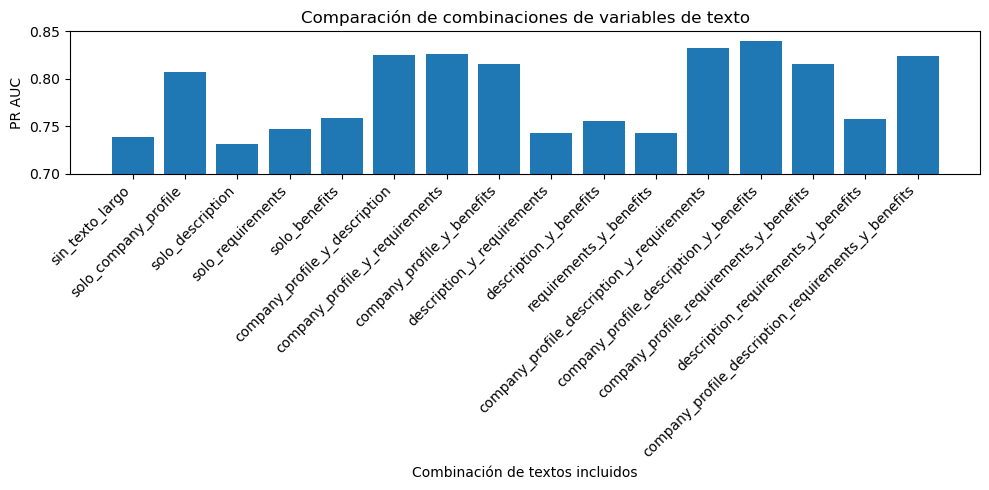

,Prueba,Textos incluidos,PR AUC
0,sin_texto_largo,Ninguno,0.738262
1,solo_company_profile,company_profile,0.807306
2,solo_description,description,0.731087
3,solo_requirements,requirements,0.747059
4,solo_benefits,benefits,0.758598
5,company_profile_y_description,"company_profile, description",0.825040
6,company_profile_y_requirements,"company_profile, requirements",0.825945
7,company_profile_y_benefits,"company_profile, benefits",0.815696
8,description_y_requirements,"description, requirements",0.742584
9,description_y_benefits,"description, benefits",0.755263


In [22]:
plt.figure(figsize=(10, 5))
plt.bar(
    tabla_resultados_combinaciones["Prueba"],
    tabla_resultados_combinaciones["PR AUC"]
)

plt.ylim(0.70, 0.85)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Combinación de textos incluidos")
plt.ylabel("PR AUC")
plt.title("Comparación de combinaciones de variables de texto")
plt.tight_layout()
plt.show()

tabla_resultados_combinaciones

## Elegir k variables con mas correlacion

Mejor resultado:


,k,PR AUC
6,9,0.842764


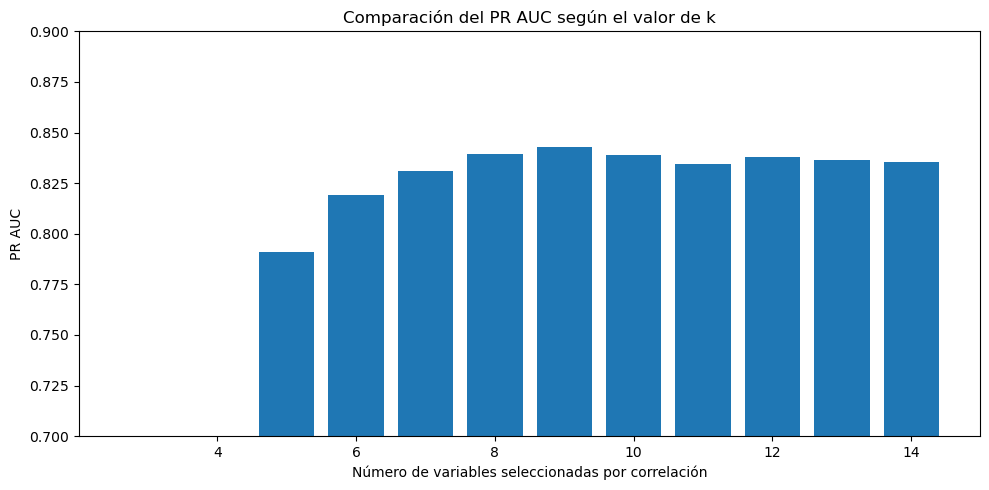

,k,PR AUC
6,9,0.842764
5,8,0.839310
7,10,0.838981
9,12,0.837760
10,13,0.836661
11,14,0.835457
8,11,0.834347
4,7,0.831160
3,6,0.818983
2,5,0.790773


In [24]:
resultados_k = []

# Mejor combinación de textos encontrada
columnas_texto_mejor = [
    "company_profile",
    "description",
    "benefits"
]

# Columnas categóricas que se usan en esta prueba
cols_categoricas_prueba = cols_base_categoricas + columnas_texto_mejor

# Número total de variables que entran antes del selector
n_variables_total = len(cols_categoricas_prueba) + len(cols_numericas)

transformer = ColumnTransformer(transformers=[
    ("imputar_categoricas",
        impute.SimpleImputer(strategy="constant", fill_value="unk"),
        cols_categoricas_prueba),

    ("imputar_salario",
        discretizador_salario(),
        col_salario),

    ("imputar_numericas",
        impute.SimpleImputer(strategy="constant", fill_value=-1),
        cols_numericas),

    ("dropear_id",
        "drop",
        col_id)
],
    remainder="drop",
    verbose_feature_names_out=False
)


numerizar = ColumnTransformer(transformers=[
    ("target_enc",
        preprocessing.TargetEncoder(smooth="auto", random_state=semilla),
        cols_categoricas_prueba + col_salario),

    ("scaler_numericas",
        preprocessing.StandardScaler(),
        cols_numericas)
],
    remainder="drop",
    verbose_feature_names_out=False
)


for k in range(3, n_variables_total + 1):

    pipeline = Pipeline([
        ("limpiaEspacios", limpiar_espacios()),
        ("minusculizar", minusculizar()),
        ("quitarSimbolos", quitar_simbolos()),
        ("quitarTildes", quitar_tildes()),
        ("rellenar", transformer),
        ("numerizar_y_escalar", numerizar),
        ("seleccion_variables", SelectorCorrelacion(k=k)),
        ("knn", KNeighborsClassifier())
    ])

    pipeline.fit(X_train, y_train)

    y_pred_proba = pipeline.predict_proba(X_val)[:, 1]

    pr_auc = metrics.average_precision_score(y_val, y_pred_proba)

    resultados_k.append({
        "k": k,
        "PR AUC": pr_auc
    })


tabla_resultados_k = pd.DataFrame(resultados_k)

tabla_resultados_k_ordenada = tabla_resultados_k.sort_values("PR AUC", ascending=False)

print("Mejor resultado:")
display(tabla_resultados_k_ordenada.head(1))

plt.figure(figsize=(10, 5))
plt.bar(
    tabla_resultados_k["k"],
    tabla_resultados_k["PR AUC"]
)

plt.ylim(0.70, 0.90)

plt.xlabel("Número de variables seleccionadas por correlación")
plt.ylabel("PR AUC")
plt.title("Comparación del PR AUC según el valor de k")
plt.tight_layout()
plt.show()

tabla_resultados_k_ordenada